# Binary Search Tree Network

### Imports

In [1]:
import sys
sys.path.append("..")

from networks.bst_network import BinarySearchTreeNetwork
from visualization.graph_visualization import plot_tree

### Empty Network

In [2]:
network = BinarySearchTreeNetwork()

assert network.root is None
assert network.total_communication_cost == 0

### Insert Root

In [3]:
network = BinarySearchTreeNetwork()

node = network.insert(10)

assert network.root == node
assert node.key == 10
assert node.parent is None

### BST Structure

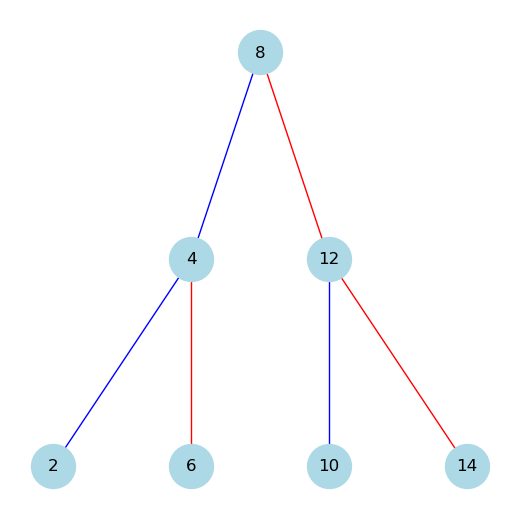

In [4]:
network = BinarySearchTreeNetwork()

network = BinarySearchTreeNetwork()

for key in [8, 4, 12, 2, 6, 10, 14]:
    network.insert(key)

assert network.root.key == 8

assert network.root.left.key == 4
assert network.root.right.key == 12

assert network.root.left.left.key == 2
assert network.root.left.right.key == 6

assert network.root.right.left.key == 10
assert network.root.right.right.key == 14

plot_tree(network)

### Search in the Network

In [5]:
node, depth = network.search(10)

assert node.key == 10
assert depth == 2

node, depth = network.search(2)

assert node.key == 2
assert depth == 2

node, depth = network.search(99)

assert node is None

### LCA

In [6]:
lca, depth = network.least_common_ancestor(2, 6)

assert lca.key == 4
assert depth == 1

lca, depth = network.least_common_ancestor(2, 14)

assert lca.key == 8
assert depth == 0

lca, depth = network.least_common_ancestor(4, 6)

assert lca.key == 4
assert depth == 1

### Communication

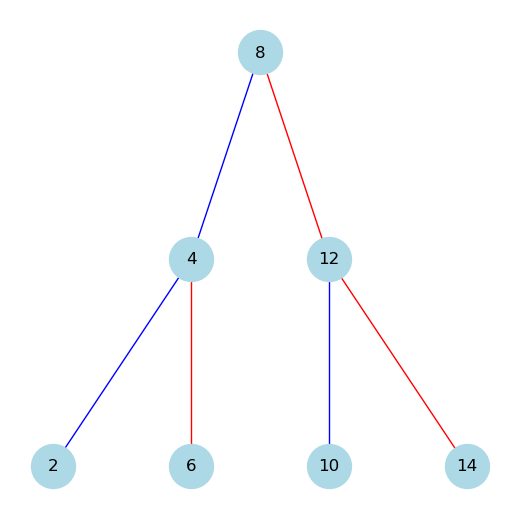

In [7]:
plot_tree(network)

In [8]:
network = BinarySearchTreeNetwork()

for key in [8, 4, 12, 2, 6, 10, 14]:
    network.insert(key)

u, v, lca = network.request(2, 6)

assert u.key == 2
assert v.key == 6
assert lca.key == 4

assert network.total_communication_cost == 2

In [9]:
network = BinarySearchTreeNetwork()

for key in [8, 4, 12, 2, 6, 10, 14]:
    network.insert(key)

network.request(2, 6)      # 2
network.request(2, 14)     # 4
network.request(10, 14)    # 2

assert network.total_communication_cost == 8

# Optimal Static Distributed BST

### Imports

In [10]:
import sys
sys.path.append("..")

from networks.optimal_network import build_optimal_bst
from visualization.graph_visualization import plot_tree

### Single Node

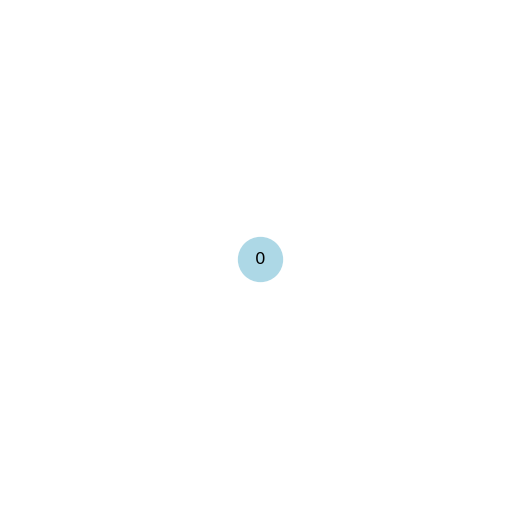

In [11]:
R = [
    [0]
]

net = build_optimal_bst(R)

assert net.root.key == 0
assert net.root.left == None
assert net.root.right == None
assert net.root.parent == None

plot_tree(net)

### Two Nodes

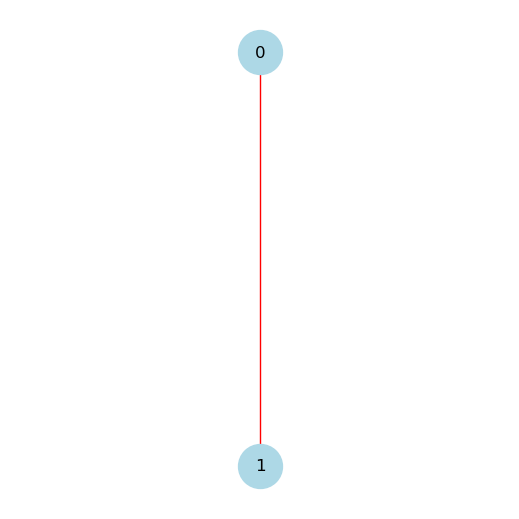

In [12]:
R = [
    [0, 10],
    [10, 0]
]

net = build_optimal_bst(R)

assert net.root.key in [0, 1]

plot_tree(net)

### Uniform Communication on 3 Keys

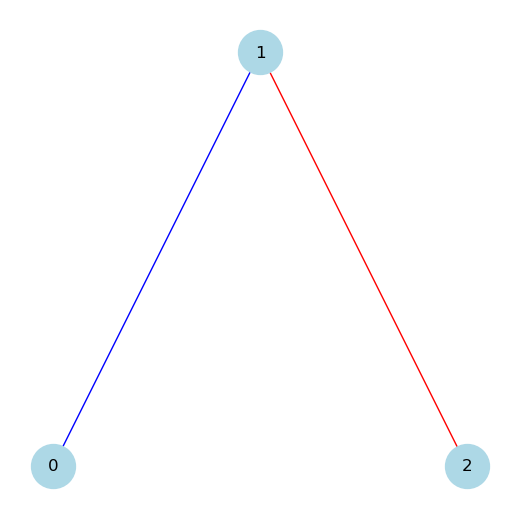

In [13]:
R = [
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]

net = build_optimal_bst(R)

assert net.root.key == 1

plot_tree(net)

### Path-like Communication

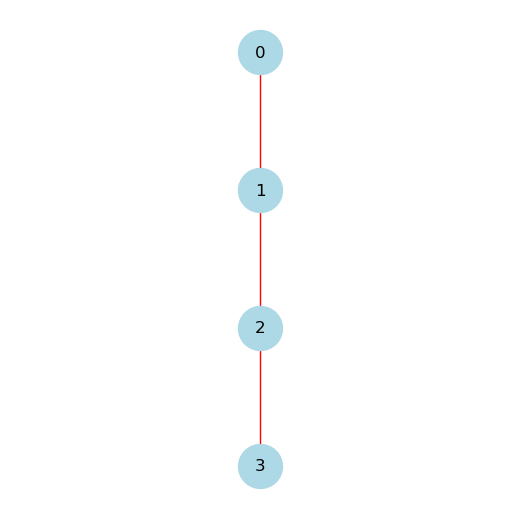

In [14]:
R = [
    [0,10,0,0],
    [10,0,10,0],
    [0,10,0,10],
    [0,0,10,0]
]

net = build_optimal_bst(R)

assert net.root.key == 0

plot_tree(net)

### Larger Network

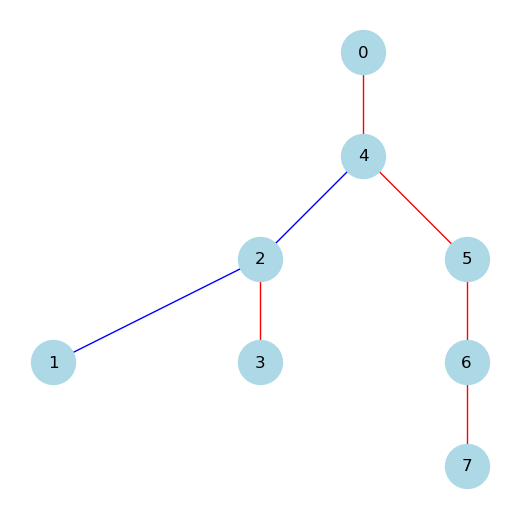

In [15]:
R = [
[ 0, 0, 0, 0, 0, 0, 0, 0], 
[ 0, 0, 0, 50, 0, 50, 0, 0], 
[ 0, 0, 0, 0, 20, 0, 0, 0], 
[ 0, 0, 0, 0, 0, 0, 0, 0], 
[ 30, 0, 0, 0, 0, 0, 0, 0], 
[ 0, 100, 100, 0, 0, 0, 0, 0], 
[ 0, 0, 0, 0, 0, 0, 0, 0], 
[ 0, 0, 0, 0, 0, 0, 0, 0], 
]

net = build_optimal_bst(R)

plot_tree(net)


### Strong Communication Pairs

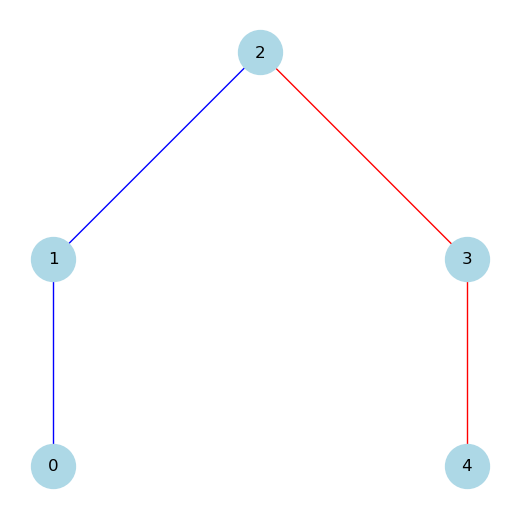

In [16]:
R = [
# 0  1   2   3  4
 [0, 8,  1,  0, 0],  # 0
 [8, 0, 12,  2, 0],  # 1
 [1,12,  0, 12, 1],  # 2
 [0, 2, 12,  0, 8],  # 3
 [0, 0,  1,  8, 0]   # 4
]

net = build_optimal_bst(R)

plot_tree(net)

### Star Network

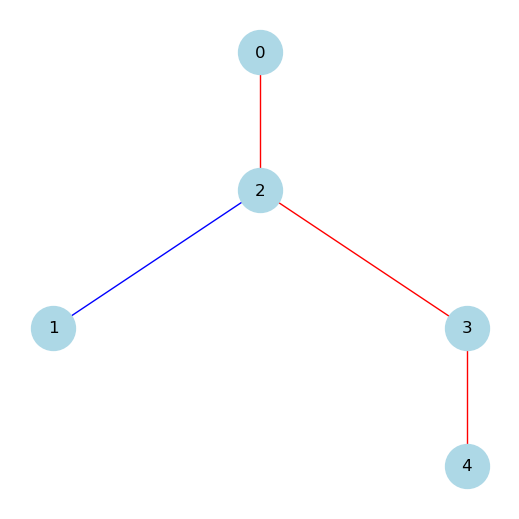

In [17]:
R = [
# 0  1   2   3   4
 [0, 0, 20, 0, 0],
 [0, 0, 20, 0, 0],
 [20,20, 0,20,20],
 [0, 0, 20, 0, 0],
 [0, 0, 20, 0, 0]
]

net = build_optimal_bst(R)

plot_tree(net)

In [18]:
from networks.optimal_network import optimal_static_network_roots

R = [
# 0  1   2   3   4
 [0, 0, 20, 0, 0],
 [0, 0, 20, 0, 0],
 [20,20, 0,20,20],
 [0, 0, 20, 0, 0],
 [0, 0, 20, 0, 0]
]

roots = optimal_static_network_roots(R)
roots

[[0, 0, 2, 0, 0],
 [-1, 1, 2, 2, 2],
 [-1, -1, 2, 2, 2],
 [-1, -1, -1, 3, 3],
 [-1, -1, -1, -1, 4]]

# SplayNet

### Imports

In [19]:
import sys
sys.path.append("..")

from networks.splaynet import SplayNet
from visualization.graph_visualization import plot_tree

### Insert

In [20]:
net = SplayNet()

for key in [10, 5, 15, 3, 7, 12, 20]:
    net.insert(key)

assert net.root.key == 10

assert net.root.left.key == 5
assert net.root.right.key == 15

assert net.root.left.left.key == 3
assert net.root.left.right.key == 7

assert net.root.right.left.key == 12
assert net.root.right.right.key == 20

### Search

In [21]:
net = SplayNet()

for key in [10, 5, 15, 3, 7]:
    net.insert(key)

assert net.search(10).key == 10
assert net.search(5).key == 5
assert net.search(7).key == 7

assert net.search(999) is None

### LCA

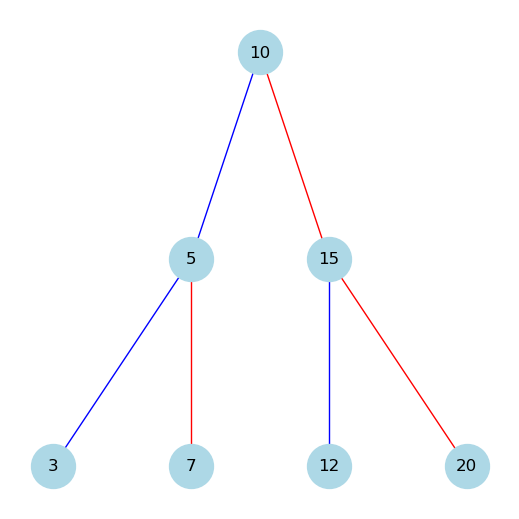

In [22]:
net = SplayNet()

for key in [10, 5, 15, 3, 7, 12, 20]:
    net.insert(key)

plot_tree(net)

In [23]:
lca  = net.least_common_ancestor(3, 7)
assert lca.key == 5

lca = net.least_common_ancestor(3, 20)
assert lca.key == 10

lca = net.least_common_ancestor(12, 20)
assert lca.key == 15

lca = net.least_common_ancestor(12, 15)
assert lca.key == 15

### Right Rotation

In [24]:
net = SplayNet()

for key in [10, 5, 3]:
    net.insert(key)

node = net.search(5)

net.rotate_right(node)

assert net.root.key == 5

assert net.root.left.key == 3
assert net.root.right.key == 10

assert net.root.left.parent is net.root
assert net.root.right.parent is net.root

### Left Rotation

In [25]:
net = SplayNet()

for key in [10, 15, 20]:
    net.insert(key)

node = net.search(15)

net.rotate_left(node)

assert net.root.key == 15

assert net.root.left.key == 10
assert net.root.right.key == 20

assert net.root.left.parent is net.root
assert net.root.right.parent is net.root

print("Left rotation test passed")

Left rotation test passed


### Request - LCA is the Root

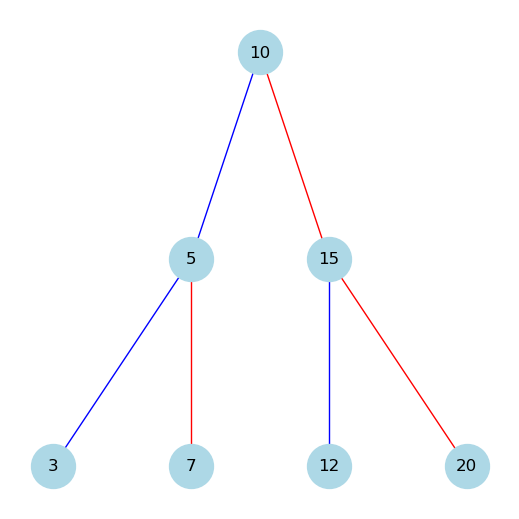

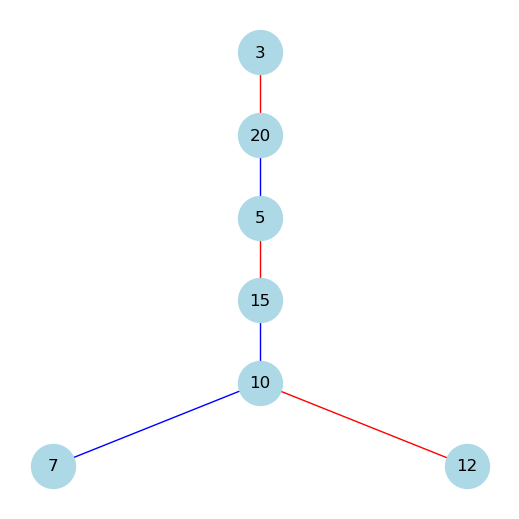

In [26]:
net = SplayNet()

for key in [10, 5, 15, 3, 7, 12, 20]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(3, 20)

assert s.key == 3
assert t.key == 20
assert lca.key == 10

assert net.root.key == 3

plot_tree(net)

### Request - LCA is the Sender

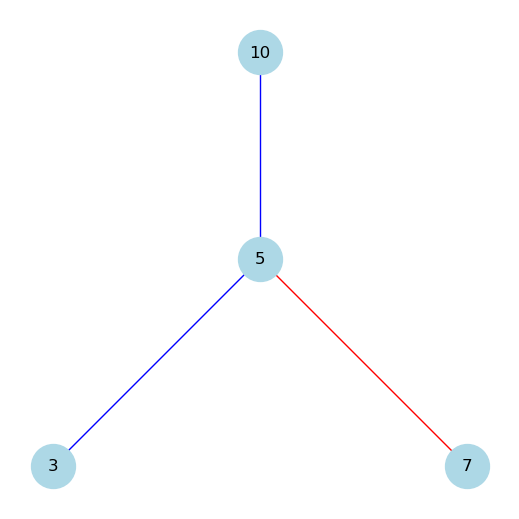

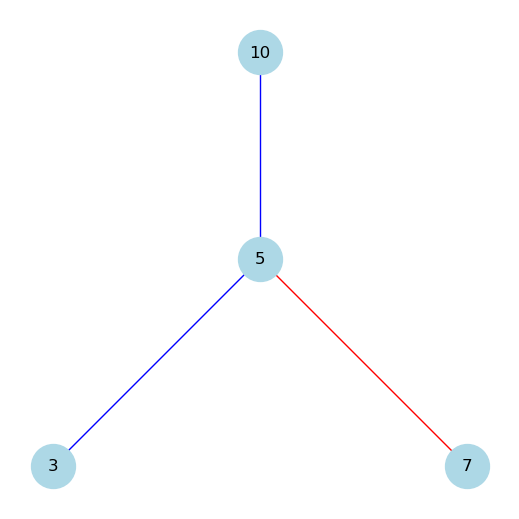

In [27]:
net = SplayNet()

for key in [10, 5, 3, 7]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(5, 3)

assert s.key == 5
assert t.key == 3
assert lca.key == 5

plot_tree(net)

### Request - LCA is the Receiver

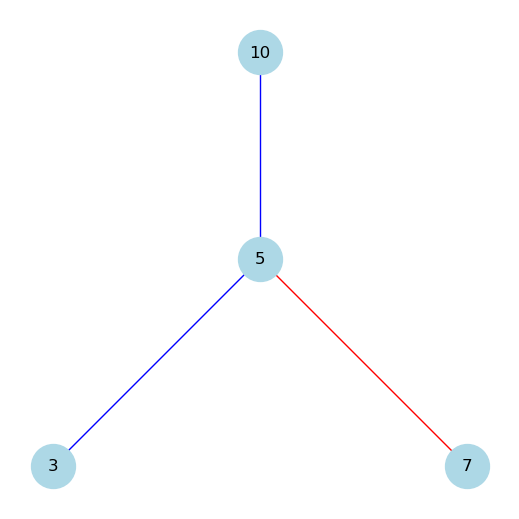

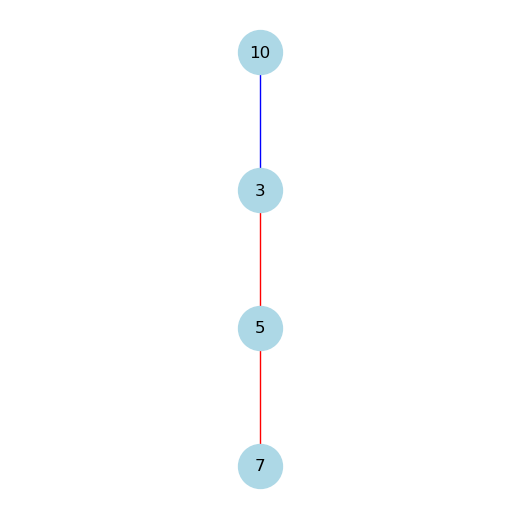

In [28]:
net = SplayNet()

for key in [10, 5, 3, 7]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(3, 5)

assert s.key == 3
assert t.key == 5
assert lca.key == 5

plot_tree(net)

### Request - Both Nodes in Left Subtree

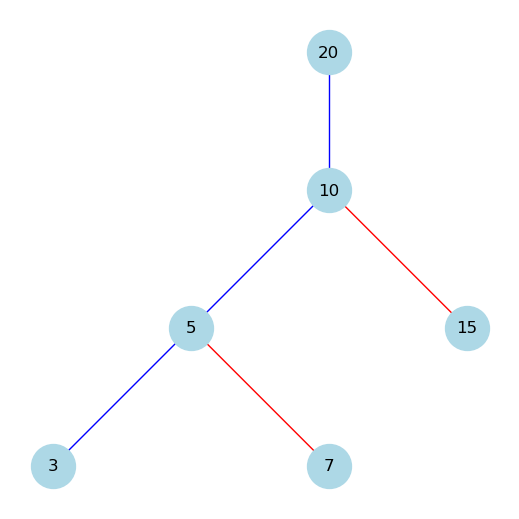

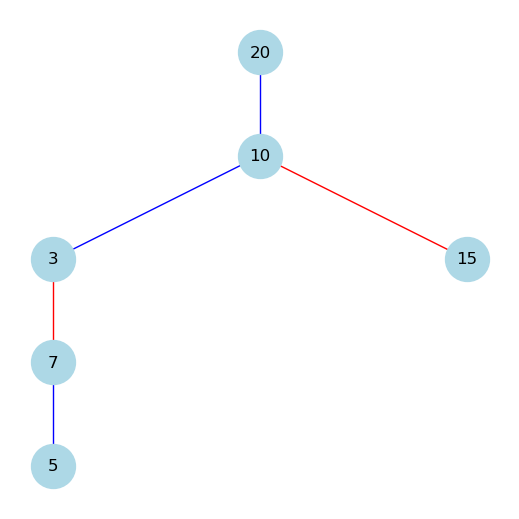

In [29]:
net = SplayNet()

for key in [20, 10, 5, 15, 3, 7]:
    net.insert(key)

plot_tree(net)

s, t, lca = net.request(3, 7)

assert s.key == 3
assert t.key == 7
assert lca.key == 5

plot_tree(net)

### Rotation Counter

In [30]:
net = SplayNet()

for key in [10, 5, 15, 3, 20]:
    net.insert(key)

assert net.total_communication_cost == 0
assert net.rotations == 0 

net.request(3, 20)
assert net.rotations == 5
assert net.total_communication_cost == 1

In [31]:
net = SplayNet()

for key in [20, 10, 5, 3, 7]:
    net.insert(key)

net.request(3, 7)

assert net.rotations ==  2
assert net.total_communication_cost == 1

In [32]:
net = SplayNet()

for key in [20, 10, 5, 3, 7]:
    net.insert(key)

for _ in range(10):
    net.request(3, 7)

assert net.rotations ==  2
assert net.total_communication_cost == 10